In [6]:
# ============================================================
# PROYECTO 3 — Detección de Fraude en Tarjetas de Crédito
# Dataset: Credit Card Fraud Detection (Kaggle - ULB)
# Autor: Robert Alexis Robles Sánchez
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cargar dataset
df = pd.read_csv(r'C:\Users\Roberth\Documents\Power BI Proyect\proyecto3-fraude-bancario\data\creditcard.csv')

# Primera inspección
print("✅ Dataset cargado correctamente")
print(f"📊 Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"\n🔍 Tipos de datos:\n{df.dtypes}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Dataset cargado correctamente
📊 Filas: 284,807 | Columnas: 31

🔍 Tipos de datos:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

📋 Primeras filas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
# ============================================================
# CELDA 2 — Análisis básico y detección de desbalance
# ============================================================

print("=" * 50)
print("RESUMEN GENERAL DEL DATASET")
print("=" * 50)
print(f"\nTotal transacciones: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nValores nulos:\n{df.isnull().sum().sum()} (total)")

# Distribución de fraude
fraude = df['Class'].value_counts()
pct_fraude = df['Class'].value_counts(normalize=True) * 100

print("\n" + "=" * 50)
print("DISTRIBUCIÓN DE CLASES")
print("=" * 50)
print(f"✅ Legítimas (0): {fraude[0]:,} ({pct_fraude[0]:.3f}%)")
print(f"🚨 Fraudes  (1): {fraude[1]:,} ({pct_fraude[1]:.3f}%)")

# Estadísticas del monto
print("\n" + "=" * 50)
print("ESTADÍSTICAS DE MONTO (Amount)")
print("=" * 50)
print(df['Amount'].describe().round(2))

RESUMEN GENERAL DEL DATASET

Total transacciones: 284,807
Columnas: 31

Valores nulos:
0 (total)

DISTRIBUCIÓN DE CLASES
✅ Legítimas (0): 284,315 (99.827%)
🚨 Fraudes  (1): 492 (0.173%)

ESTADÍSTICAS DE MONTO (Amount)
count    284807.00
mean         88.35
std         250.12
min           0.00
25%           5.60
50%          22.00
75%          77.16
max       25691.16
Name: Amount, dtype: float64


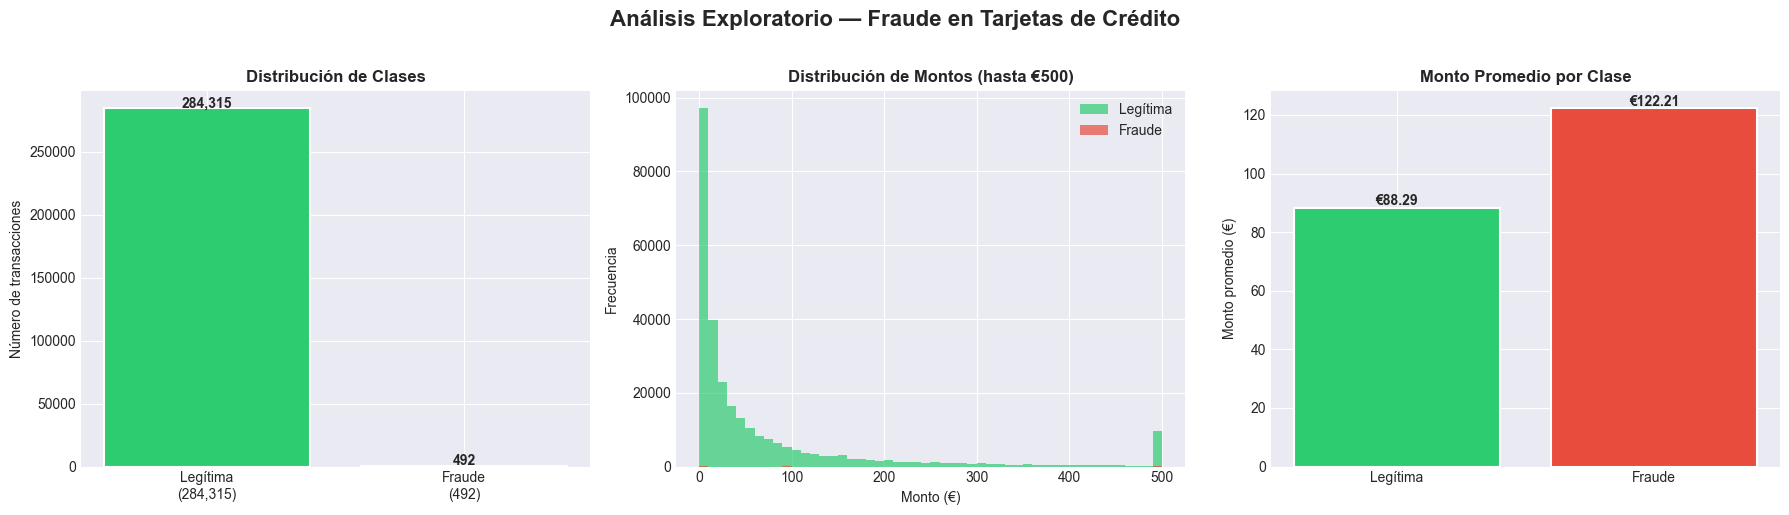

✅ Gráfico guardado


In [8]:
# ============================================================
# CELDA 3 — Visualizaciones: Desbalance y distribución de montos
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Exploratorio — Fraude en Tarjetas de Crédito', 
             fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1 — Distribución de clases
clases = ['Legítima\n(284,315)', 'Fraude\n(492)']
valores = [284315, 492]
colores = ['#2ecc71', '#e74c3c']
axes[0].bar(clases, valores, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Número de transacciones')
for i, v in enumerate(valores):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Gráfico 2 — Distribución del monto (legítimas vs fraude)
df[df['Class']==0]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.7, color='#2ecc71', label='Legítima')
df[df['Class']==1]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.7, color='#e74c3c', label='Fraude')
axes[1].set_title('Distribución de Montos (hasta €500)', fontweight='bold')
axes[1].set_xlabel('Monto (€)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# Gráfico 3 — Monto promedio por clase
avg_amount = df.groupby('Class')['Amount'].mean()
axes[2].bar(['Legítima', 'Fraude'], avg_amount.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[2].set_title('Monto Promedio por Clase', fontweight='bold')
axes[2].set_ylabel('Monto promedio (€)')
for i, v in enumerate(avg_amount.values):
    axes[2].text(i, v + 1, f'€{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()

# Guardar
import os
os.makedirs('../graficas', exist_ok=True)
plt.savefig('../graficas/01_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado")

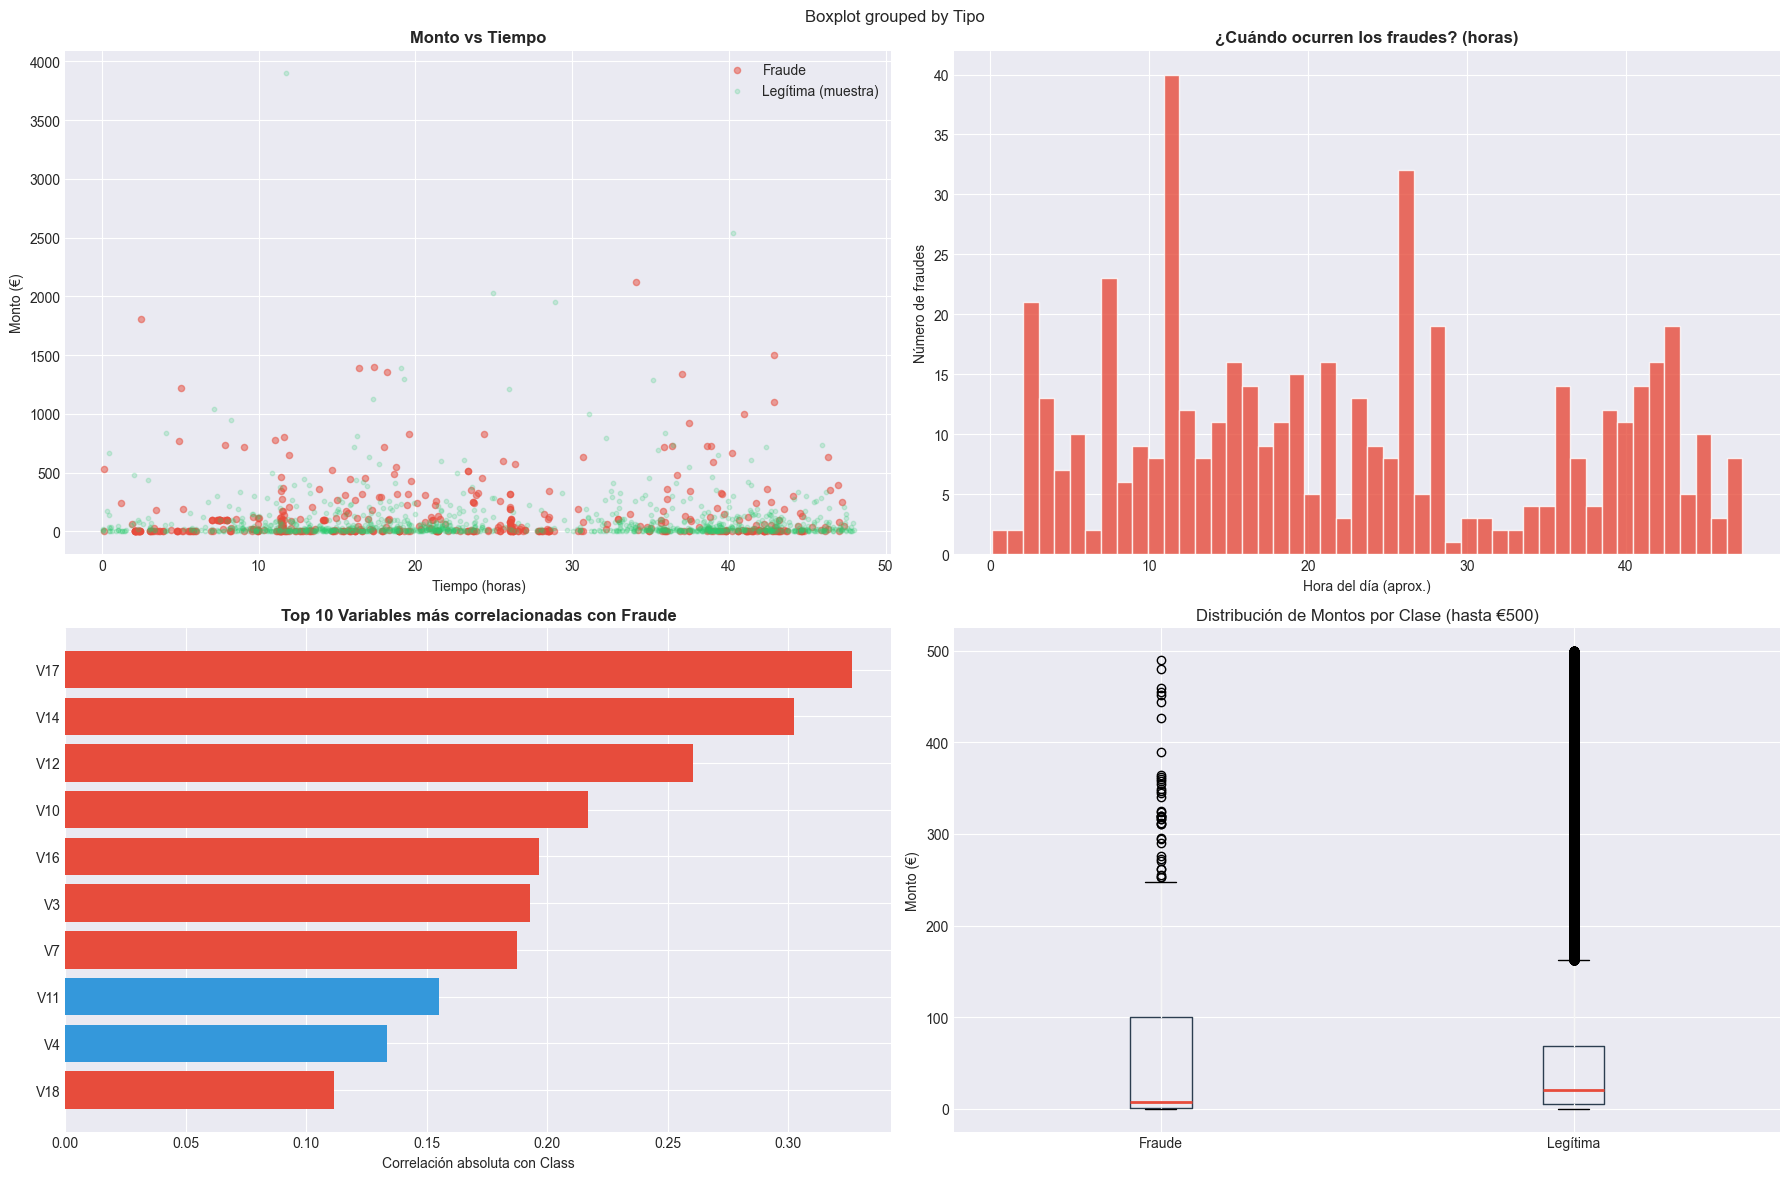

✅ Gráfico guardado


In [9]:
# ============================================================
# CELDA 4 — Análisis temporal y correlación con fraude
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis Temporal y Correlaciones', 
             fontsize=16, fontweight='bold')

# Gráfico 1 — Fraudes vs tiempo
df_fraude = df[df['Class']==1]
df_legitima = df[df['Class']==0]

axes[0,0].scatter(df_fraude['Time']/3600, df_fraude['Amount'], 
                  alpha=0.5, color='#e74c3c', s=20, label='Fraude')
axes[0,0].scatter(df_legitima.sample(1000)['Time']/3600, 
                  df_legitima.sample(1000)['Amount'],
                  alpha=0.2, color='#2ecc71', s=10, label='Legítima (muestra)')
axes[0,0].set_title('Monto vs Tiempo', fontweight='bold')
axes[0,0].set_xlabel('Tiempo (horas)')
axes[0,0].set_ylabel('Monto (€)')
axes[0,0].legend()

# Gráfico 2 — Distribución temporal de fraudes
axes[0,1].hist(df_fraude['Time']/3600, bins=48, color='#e74c3c', 
               alpha=0.8, edgecolor='white')
axes[0,1].set_title('¿Cuándo ocurren los fraudes? (horas)', fontweight='bold')
axes[0,1].set_xlabel('Hora del día (aprox.)')
axes[0,1].set_ylabel('Número de fraudes')

# Gráfico 3 — Top 10 features más correlacionadas con fraude
correlaciones = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top10 = correlaciones.head(10)
colores_corr = ['#e74c3c' if df.corr()['Class'][i] < 0 else '#3498db' 
                for i in top10.index]
axes[1,0].barh(top10.index[::-1], top10.values[::-1], color=colores_corr[::-1])
axes[1,0].set_title('Top 10 Variables más correlacionadas con Fraude', 
                     fontweight='bold')
axes[1,0].set_xlabel('Correlación absoluta con Class')

# Gráfico 4 — Boxplot monto por clase
df_plot = df.copy()
df_plot['Tipo'] = df_plot['Class'].map({0:'Legítima', 1:'Fraude'})
df_plot[df_plot['Amount'] < 500].boxplot(
    column='Amount', by='Tipo', ax=axes[1,1],
    boxprops=dict(color='#2c3e50'),
    medianprops=dict(color='#e74c3c', linewidth=2))
axes[1,1].set_title('Distribución de Montos por Clase (hasta €500)', 
                     fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Monto (€)')
plt.sca(axes[1,1])
plt.title('Distribución de Montos por Clase (hasta €500)')

plt.tight_layout()
plt.savefig('../graficas/02_analisis_temporal_correlacion.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado")

In [10]:
# ============================================================
# CELDA 5 — Modelo de Detección de Fraude
# Random Forest con manejo de desbalance
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

print("⚙️ Preparando datos...")

# Features y target
X = df.drop('Class', axis=1)
y = df['Class']

# Escalar Amount y Time (las únicas no-PCA)
scaler = StandardScaler()
X = X.copy()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"   Fraudes en test: {y_test.sum()} de {len(y_test):,}")

# Modelo con class_weight para manejar desbalance
print("\n⚙️ Entrenando Random Forest...")
modelo = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo.fit(X_train, y_train)
print("✅ Modelo entrenado")

# Predicciones
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

# Resultados
print("\n" + "="*50)
print("RESULTADOS DEL MODELO")
print("="*50)
print(classification_report(y_test, y_pred, 
      target_names=['Legítima', 'Fraude']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

⚙️ Preparando datos...
✅ Train: 227,845 | Test: 56,962
   Fraudes en test: 98 de 56,962

⚙️ Entrenando Random Forest...
✅ Modelo entrenado

RESULTADOS DEL MODELO
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9529


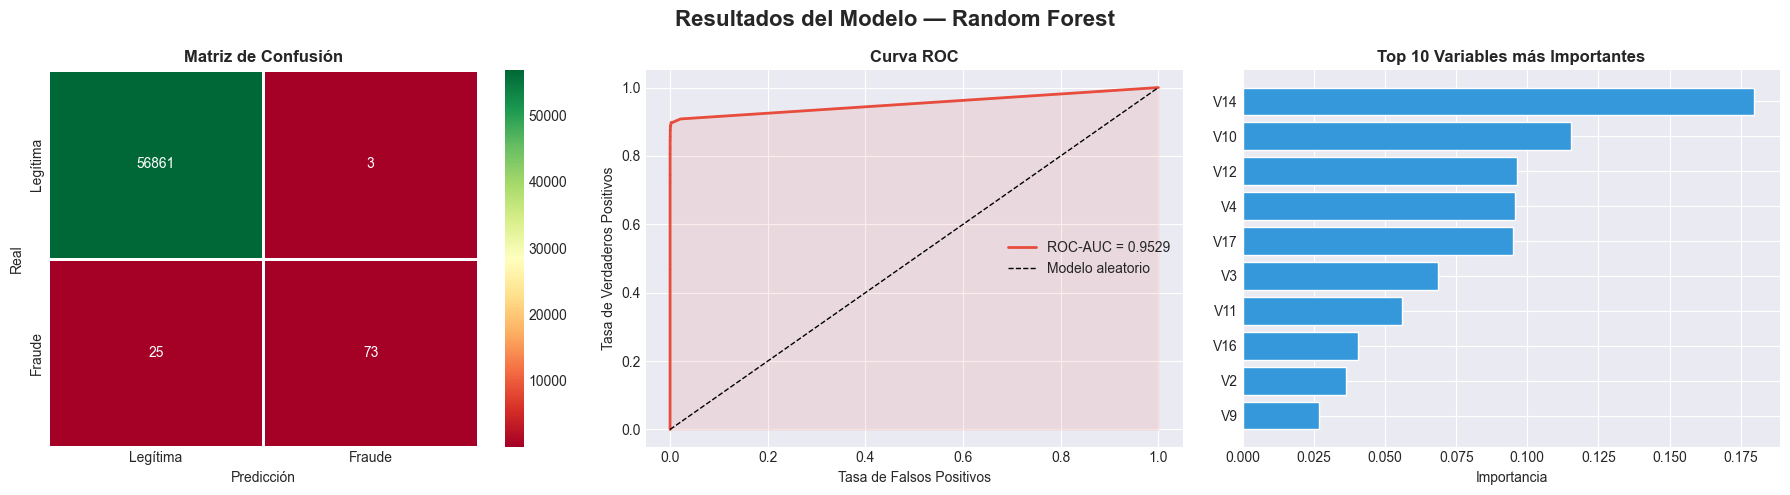

✅ Gráfico guardado

🎯 ROC-AUC final: 0.9529
✅ Proyecto 3 — EDA y modelo completados


In [11]:
# ============================================================
# CELDA 6 — Visualización de resultados del modelo
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Resultados del Modelo — Random Forest', 
             fontsize=16, fontweight='bold')

# Gráfico 1 — Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'],
            ax=axes[0], linewidths=2)
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

# Gráfico 2 — Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, 
             label=f'ROC-AUC = {auc:.4f}')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Modelo aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend()

# Gráfico 3 — Feature importance top 10
importancias = pd.Series(modelo.feature_importances_, 
                          index=X.columns).sort_values(ascending=False).head(10)
axes[2].barh(importancias.index[::-1], importancias.values[::-1], 
             color='#3498db', edgecolor='white')
axes[2].set_title('Top 10 Variables más Importantes', fontweight='bold')
axes[2].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('../graficas/03_resultados_modelo.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado")
print(f"\n🎯 ROC-AUC final: {auc:.4f}")
print("✅ Proyecto 3 — EDA y modelo completados")

# 🔍 Proyecto 3 — Detección de Fraude en Tarjetas de Crédito

**Autor:** Robert Alexis Robles Sánchez  
**Dataset:** Credit Card Fraud Detection — Kaggle (ULB Machine Learning Group)  
**Stack:** Python · pandas · scikit-learn · matplotlib · seaborn